In [1]:
# 전이학습에 대해서 알아보아요
# 당연히 전이학습을 하려면 Pretrained Network 이 있어야해요
# 이미 누군가에 의해서 만들어진(학습된) CNN모델이 있어야해요
# 이런 Pretrained Network은 그 종류가 상당히 많아요
# 그 중 대표적인 모델은 VGG16, VGG19(학습용), MS의 Resnet, Google의 Inception
# mobilenet(모델의 정확도는 낮지만 속도가 빠르고 가벼워요. 모바일에 사용하기 좋다)
# EfficientNet(성능이 좋지만 조금 느릴 수 있다)
# 그 외 별의 별 모델들이 있어요~

# Pretrained Network(CNN) 모델에서 우리가 사용할 수 있는 부문은
# 특징 추춣부분이에요. 이 부분을 통해서 개와 고양이의 특징을 추출하고
# 머신러닝에서 배운 학습기(classifier)를 이용해서 머신러닝을 구현하면 되요!

# 결국 우리가 재 사용하는 layer는 Conv2D, MaxPooling2D 예요.
# Conv2D가 여러개 있을거고 MaxPooling2D도 여러개 있겠죠.
# 하위 convolution layer는 입력데이터의 국소적인 특징을 추출(질감, 선의 형태)
# 하위 레이어는 입력에 가깝고 상위 레이어는 출력에 가깝다고 표현함. 하위 레이어는 지역적, 국소적인 특징을 뽑는다. 상위 레이어은 
# 상위 convolution layer는 입력데이터의 형태적인 특징을 추출(눈, 코와 같은)

# 원래 다른 이미지(imagenet와 같은)로 만든 필터지만 우리의 개와 고양이의 특징을
# 추출하는데도 잘 사용할 수 있어요! -> 그래서 가져다 쓰는데 문제가 없어요

# VGG16은 tensorflow keras 안에서 제공되요
# 진짜 모델이 keras안에 포함된건 아니구요. keras를 이용하면 쉽게 다운로드 받을 수 있어요!

In [4]:
from tensorflow.keras.applications import VGG16

model_base = VGG16(weights= 'imagenet',  #가중치의 출처 'imagenet' / 'xxx.h5'
                  include_top= False,  # 분류기를 포함할거니 코드 필터만 사용할거니까 false 사용
                  input_shape= (150,150,3))
model_base.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 150, 150, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 150, 150, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 150, 150, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 75, 75, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 75, 75, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 75, 75, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 37, 37, 128)       0     

In [ ]:
# 우리의 데이터를 model_base에 통과시켜서 그 결과인
# feature map을 ndarray에 저장할거에요!

# 그런 다음에 이 ndarray를 이용해서 classifier에 입력으로 넣어서 학습할거에요!

In [5]:
import os # 경로를 합칠 수 있으니
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16


In [6]:
model_base = VGG16(weights='imagenet',
                  include_top=False,
                  input_shape=(150,150,3))

In [7]:
base_dir = './data/cat_dog_small'
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

In [8]:
datagen = ImageDataGenerator(rescale=1/255)
batch_size = 20

In [11]:
# 특정 폴더안에서 이미지 파일을 읽어서
# 해당 이미지의 픽셀을 추출해서 리턴하는게 아니라
# 이 이미지의 특징을 뽑고 그 특징 이미지의 픽셀데이터를 리턴하는 함수.

def extract_feature(directory, sample_count):
    # 입력이미지의 특징을 추출해서 ndarray로 리턴
    features = np.zeros(shape=(sample_count,4,4,512))
    labels = np.zeros(shape=(sample_count,))

    generator = datagen.flow_from_directory(
        directory,
        classes=['cats', 'dogs'],
        target_size=(150,150),
        batch_size=batch_size,
        class_mode='binary'
    )

    i = 0
    for x_data_batch, t_data_batch in generator:
        feature_batch = model_base.predict(x_data_batch)   # shape : (20,4,4,512)
        features[i*batch_size:(i+1)*batch_size] = feature_batch
        labels[i*batch_size:(i+1)*batch_size] = t_data_batch
        i+=1
        
        if i*batch_size >= sample_count:
            break;

    return (features, labels)
    

In [19]:
train_features, train_labels = extract_feature(train_dir,2000)

Found 2000 images belonging to 2 classes.
1/1 [==============================] - 0s 18ms/step


In [20]:
validation_features, validation_labels = extract_feature(validation_dir,1000)
test_features, test_labels = extract_feature(test_dir,1000)

Found 1000 images belonging to 2 classes.
1/1 [==============================] - 0s 21ms/step
Found 1000 images belonging to 2 classes.
1/1 [==============================] - 0s 16ms/step


In [21]:
# train_features(4차원), train_lebels(1차원)
# validation_features, validation_lebels
# test_features, test_lebels

In [22]:
x_data_train = train_features.reshape(2000, 4*4*512) #2차원으로 변경해야되니까
t_data_train = train_labels.reshape(-1,1)

In [23]:
x_data_validation = validation_features.reshape(1000, 4*4*512) #2차원으로 변경해야되니까
t_data_validation = validation_labels.reshape(-1,1)

In [24]:
x_data_test = test_features.reshape(1000, 4*4*512) #2차원으로 변경해야되니까
t_data_test = test_labels.reshape(-1,1)

In [27]:
# classifier 구현

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout, Dense
from tensorflow.keras.optimizers import Adam

model = Sequential()

model.add(Dense(units=256,
               activation='relu',
               input_shape=(4*4*512,)))
model.add(Dropout(rate=0.5))
model.add(Dense(units=1,
               activation='sigmoid'))

model.compile(optimizer=Adam(learning_rate=1e-4),
             loss='binary_crossentropy',
             metrics=['accuracy'])

In [28]:
history = model.fit(x_data_train,
                   t_data_train,
                   epochs=30,
                   batch_size=20,
                   validation_data=(x_data_validation, t_data_validation),
                   verbose=1)

Epoch 1/30
100/100 [==============================] - 2s 8ms/step - loss: 0.4633 - accuracy: 0.7720 - val_loss: 0.3041 - val_accuracy: 0.8690
Epoch 2/30
100/100 [==============================] - 0s 3ms/step - loss: 0.2810 - accuracy: 0.8825 - val_loss: 0.2674 - val_accuracy: 0.8890
Epoch 3/30
100/100 [==============================] - 0s 3ms/step - loss: 0.2176 - accuracy: 0.9185 - val_loss: 0.2451 - val_accuracy: 0.9040
Epoch 4/30
100/100 [==============================] - 0s 3ms/step - loss: 0.1940 - accuracy: 0.9275 - val_loss: 0.2351 - val_accuracy: 0.9040
Epoch 5/30
100/100 [==============================] - 0s 3ms/step - loss: 0.1606 - accuracy: 0.9430 - val_loss: 0.2403 - val_accuracy: 0.9100
Epoch 6/30
100/100 [==============================] - 0s 3ms/step - loss: 0.1487 - accuracy: 0.9395 - val_loss: 0.2340 - val_accuracy: 0.9060
Epoch 7/30
100/100 [==============================] - 0s 3ms/step - loss: 0.1161 - accuracy: 0.9660 - val_loss: 0.2341 - val_accuracy: 0.9080
Epoch 

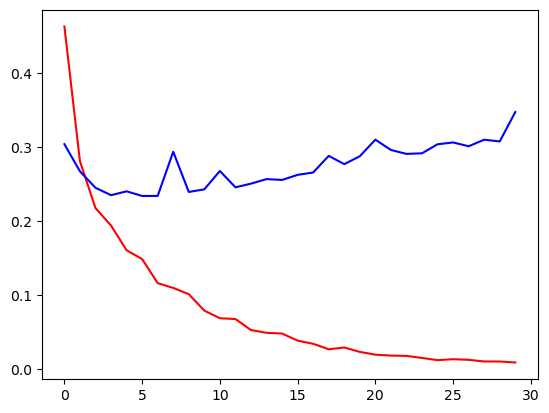

In [29]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],color='r')
plt.plot(history.history['val_loss'],color='b')

plt.show()

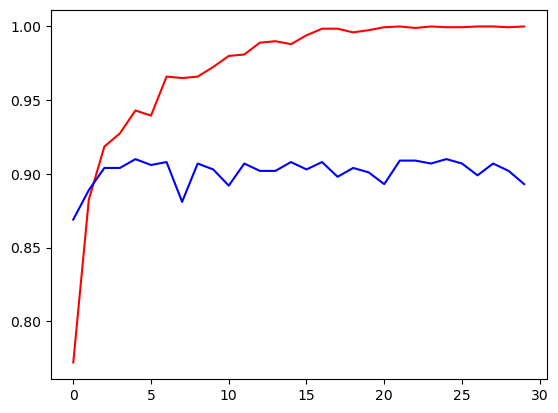

In [31]:
plt.plot(history.history['accuracy'],color='r')
plt.plot(history.history['val_accuracy'],color='b')

plt.show()